In [ ]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# ===============================
# 2. LOAD DATASET
# ===============================
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = "Fake"
true["label"] = "True"

data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1).reset_index(drop=True)

print("Dataset size:", data.shape)



Dataset size: (44898, 5)


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

data["text"] = data["text"].apply(clean_text)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# ===============================
# 4. LABEL ENCODING
# ===============================
le = LabelEncoder()
data["label"] = le.fit_transform(data["label"])

In [ ]:
# ===============================
# 5. TRAIN-TEST SPLIT
# ===============================
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
# ===============================
# 6. TF-IDF FEATURE EXTRACTION
# ===============================
tfidf = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# ===============================
# 7. TOKENIZATION FOR CNN-LSTM
# ===============================
tokenizer = Tokenizer(num_words=100000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [ ]:
# ===============================
# 8. BUILD CNN-LSTM MODEL
# ===============================
model = Sequential()

model.add(Embedding(
    input_dim=100000,
    output_dim=50,
    input_length=max_len
))

model.add(Conv1D(
    filters=128,
    kernel_size=5,
    activation='relu'
))

model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(80, return_sequences=False))

model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# ===============================
# 9. COMPILE MODEL
# ===============================
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===============================
# 10. TRAIN MODEL
# ===============================
history = model.fit(
    X_train_pad,
    y_train_cat,
    epochs=10,
    batch_size=16,
    validation_split=0.1
)


Epoch 1/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9409 - loss: 0.1508 - val_accuracy: 0.9952 - val_loss: 0.0188
Epoch 2/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9987 - loss: 0.0055 - val_accuracy: 0.9936 - val_loss: 0.0419
Epoch 3/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accuracy: 0.9971 - val_loss: 0.0139
Epoch 4/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 1.0000 - loss: 3.4056e-04 - val_accuracy: 0.9879 - val_loss: 0.0508
Epoch 5/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9971 - val_loss: 0.0135
Epoch 6/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9999 - loss: 7.5347e-04 - val_accuracy: 0.9971 - val_loss: 0.0128
Epoch 7/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 1.0000 - loss: 8.8480e-05 - val_accuracy: 0.9984 - val_loss: 0.0121
Epoch 8/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accura

In [ ]:
# ===============================
# 11. EVALUATION
# ===============================
test_loss, test_acc = model.evaluate(X_test_pad, y_test_cat)
print("Test Accuracy:", test_acc)

y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9970 - loss: 0.0264
Test Accuracy: 0.9973273873329163
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7045
           1       1.00      1.00      1.00      6425

    accuracy                           1.00     13470
   macro avg       1.00      1.00      1.00     13470
weighted avg       1.00      1.00      1.00     13470



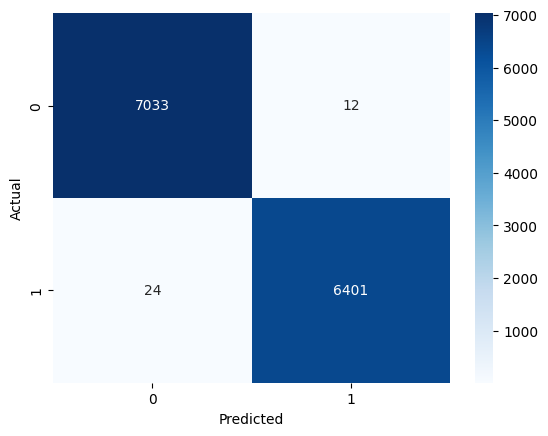

In [ ]:
# ===============================
# 12. CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

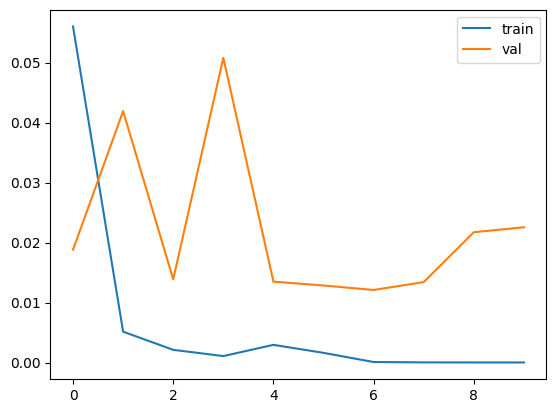

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


In [ ]:
print("\n===== Naive Bayes =====")

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

print(classification_report(y_test, nb_pred))



===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7045
           1       0.96      0.95      0.95      6425

    accuracy                           0.96     13470
   macro avg       0.96      0.96      0.96     13470
weighted avg       0.96      0.96      0.96     13470



In [ ]:
print("\n===== Logistic Regression =====")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

print(classification_report(y_test, lr_pred))



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7045
           1       0.99      0.99      0.99      6425

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



In [ ]:
print("\n===== Support Vector Machine =====")

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

print(classification_report(y_test, svm_pred))



===== Support Vector Machine =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7045
           1       1.00      1.00      1.00      6425

    accuracy                           1.00     13470
   macro avg       1.00      1.00      1.00     13470
weighted avg       1.00      1.00      1.00     13470



In [ ]:
from sklearn.metrics import accuracy_score

results = {
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "CNN-LSTM": test_acc
}

results_df = pd.DataFrame.from_dict(
    results, orient='index', columns=['Accuracy']
)

print("\n===== Model Comparison =====")
print(results_df)



===== Model Comparison =====
                     Accuracy
Naive Bayes          0.956941
Logistic Regression  0.989458
SVM                  0.995843
CNN-LSTM             0.997327


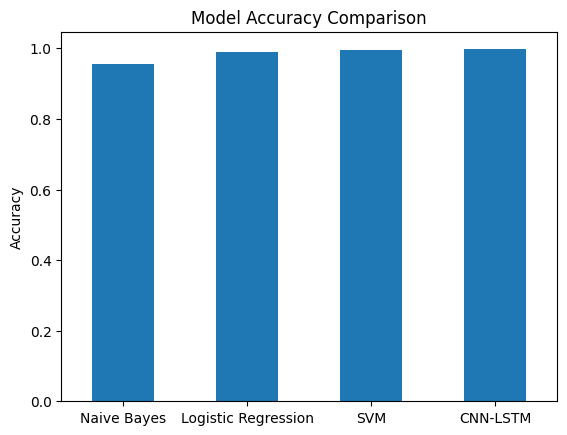

In [ ]:
results_df.plot(kind='bar', legend=False)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=0)
plt.show()
